# Titanic Dataset Survivor Detector Using 

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import AdaBoostClassifier


data_path = "../../../datasets/titanic/train.csv"
raw_df = pd.read_csv(data_path)

df = raw_df.copy().drop(columns = ['Cabin', 'Ticket', 'Name'])


## Checking Out Data

In [29]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [30]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB
None


## Cleaning and Feature Selection

In [31]:
df = pd.get_dummies(df, columns = ['Embarked'], dtype = int)

df['Sex_Encoded'] = df['Sex'].apply(lambda x: 1 if x == 'male' else 0)
df['Family'] = df['SibSp'] + df['Parch']
df['Fare'] = df['Fare'].apply(np.log1p).fillna(df.groupby('Pclass')['Fare'].transform('mean'))
df['Age'] = df['Age'].fillna(df['Age'].median())




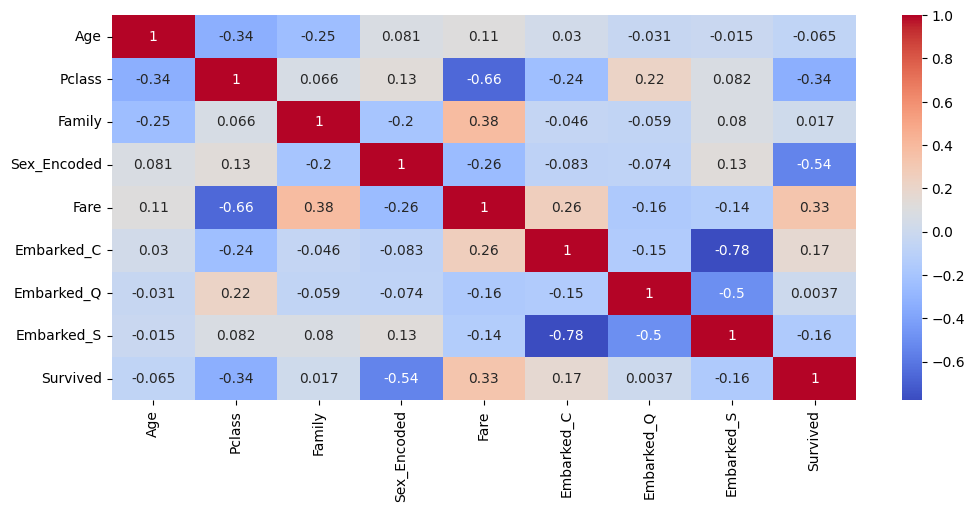

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Sex_Encoded,Family
0,1,0,3,male,22.0,1,0,2.110213,0,0,1,1,1
1,2,1,1,female,38.0,1,0,4.280593,1,0,0,0,1
2,3,1,3,female,26.0,0,0,2.188856,0,0,1,0,0
3,4,1,1,female,35.0,1,0,3.990834,0,0,1,0,1
4,5,0,3,male,35.0,0,0,2.202765,0,0,1,1,0


In [32]:
corr = df[['Age', 'Pclass', 'Family', 'Sex_Encoded', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Survived']].corr()
plt.figure(figsize = (12,5))

sns.heatmap(
    corr,
    annot = True,
    cmap = 'coolwarm',
    cbar = True 
)
plt.show()

df.head()

## Preparing Data

In [33]:
data = df.drop(columns = ['PassengerId', 'SibSp', 'Parch', 'Sex'])
X = data.drop(columns = ['Survived']).to_numpy()
y = data['Survived'].to_numpy()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



## Hyperparameter Sweep

In [34]:
results = []

n_estimators_list = [10, 50, 100, 200]
learning_rate_list = [0.1, 0.5, 1.0]

for n in n_estimators_list:
    for learning_rate in learning_rate_list:
        ada = AdaBoostClassifier(
            n_estimators=n,
            learning_rate = learning_rate,
            random_state=42,
        )

        ada.fit(X_train, y_train)

        preds = ada.predict(X_test)
        acc = accuracy_score(y_test, preds)

        results.append({
            "n_estimators": n,
            "learning_rate": learning_rate,
            "accuracy": acc,
        })


In [35]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="accuracy", ascending=False)

print("Hyperparameter Results:")
print(results_df)

Hyperparameter Results:
    n_estimators  learning_rate  accuracy
2             10            1.0  0.804469
7            100            0.5  0.804469
5             50            1.0  0.804469
4             50            0.5  0.804469
11           200            1.0  0.804469
9            200            0.1  0.804469
8            100            1.0  0.804469
1             10            0.5  0.798883
6            100            0.1  0.798883
10           200            0.5  0.798883
3             50            0.1  0.782123
0             10            0.1  0.782123


## Plot n_estimators vs Accuracy

In [36]:
n_values = [1, 5, 10, 25, 50, 100, 200]

train_scores = []
test_scores = []

for n in n_values:
    ada = AdaBoostClassifier(
        n_estimators=n,
        learning_rate=1.0,   #best from sweep
        random_state=42
    )

    ada.fit(X_train, y_train)

    # Predictions
    train_pred = ada.predict(X_train)
    test_pred = ada.predict(X_test)

    # Accuracy
    train_scores.append(accuracy_score(y_train, train_pred))
    test_scores.append(accuracy_score(y_test, test_pred))

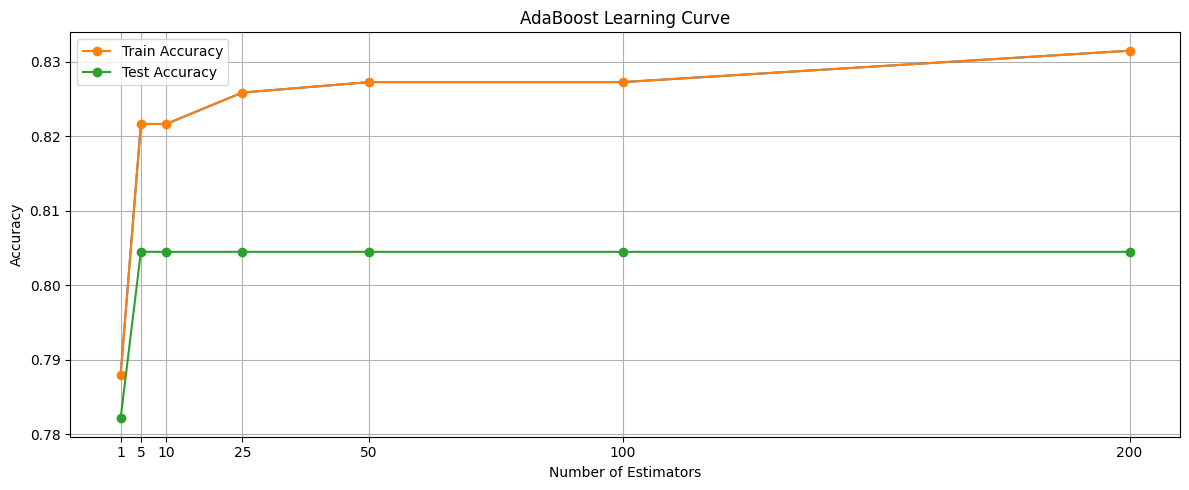

In [37]:
plt.figure(figsize = (12,5))
plt.plot(n_values, train_scores)
plt.plot(n_values, train_scores, marker="o", label="Train Accuracy")
plt.plot(n_values, test_scores, marker="o", label="Test Accuracy")

plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost Learning Curve")
plt.xticks(n_values)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()